# Gumbel/GPD return periods: ERA5 vs. reforecast (simplified)

Simplified version of `fit_gumbel_return_periods.ipynb` -- same core methodology, but with
the settings that were previously exposed as toggles (which "excl. max" convention, which CI
direction, anomaly on/off, ...) already decided and baked in, rather than left as choices.
See the full notebook for the extra sensitivity checks and diagnostics (leave-one-out
influence analysis, block maxima, the "recompute" vs "leave-one-out" excl-max convention,
etc.) if you need them again.

**Method summary:**
- Top 5% peaks-over-threshold (POT), fit via MLE (Gumbel by default; GPD optional).
- Reforecast ensemble members treated as independent samples (UNSEEN-style): annual rate =
  exceedances / (n_years * n_members).
- Reforecast bias-corrected via a proper lead-day-specific mean-climatology correction
  (model climatology minus ERA5 climatology, per calendar date).
- "ERA5 excl. max" sensitivity: how much the single hottest exceedance drives the fit, via
  leave-one-out (refit holding every other point fixed).
- Empirical (distribution-free) tail-slope cross-check, plotted as temperature anomaly (each
  dataset centered on its own mean, so different climatological biases don't distort the
  comparison), with bootstrap CI in the "probability at a fixed magnitude" direction --
  i.e. "how uncertain is the return period of this observed temperature." Optional CMIP/AMIP
  model overlays and a warming-shift arrow.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r, genpareto

## Config

In [99]:
ERA5_PATH = "../station/pnw_box_era5_filtered.nc"
REFORECAST_CSV ='../refore.csv' #"../station/reforecast_0_t0_13.csv"
LEAD_DAY = 12

DIST = "gumbel"  # "gumbel" or "gpd"
THRESHOLD_PERCENTILE = 95  # top 5%

REFERENCE_VALUE = 39.5  # 2021 PNW heatwave observed peak (degC)
REFERENCE_LABEL = "2021 PNW heatwave"

# Optional CMIP/AMIP models: {model_name: values_array}. Leave empty to skip.
# Fill this in yourself, e.g.:
#   import xarray as xr
#   cmip_dtree = xr.open_datatree("path/to/your/datatree")
#   CMIP_MODELS = {name: load_cmip_model(cmip_dtree, name, target_mmdd)["value"].values
#                  for name in ["CNRM-CM6-1", "CNRM-ESM2-1", "HadGEM3-GC31-LL", "IPSL-CM6A-LR"]}
cmip_dtree  =xr.open_datatree("../New_folder/global_temp_anomaly.zarr/", engine="zarr")
CMIP_MODELS = ["CNRM-CM6-1", "CNRM-ESM2-1", "HadGEM3-GC31-LL", "IPSL-CM6A-LR"]
CMIP_VAR = "tasmax"

CMIP_DATATREE_PATH = "../New_folder/global_temp_anomaly.zarr/"# e.g. "path/to/your/datatree"
CMIP_MODEL_NAMES = ["CNRM-CM6-1", "CNRM-ESM2-1", "HadGEM3-GC31-LL", "IPSL-CM6A-LR"]

# Warming-shift arrow on the empirical-slope plot (None to skip)
WARMING_SHIFT_DATASET = f"Reforecast day {LEAD_DAY}"
WARMING_SHIFT_DEGREES = 1.0

N_BOOTSTRAP = 1000
CI_LEVEL = 0.95
BOOTSTRAP_SEED = 0

COL = {"era5": "#ff7f0e", "era5_ci": "#ffbb78", "reforecast": "#1f77b4", "reforecast_ci": "#aec7e8",
       "reference": "#000000"}
GRID_COLOR = "#d3d3d3"



MODEL_COLORS = {
    "era5": {"color": "#ff7f0e", "ci": "#ffbb78", "marker": "^"},
    "reforecast": {"color": "#1f77b4", "ci": "#aec7e8", "marker": "o"},
    "cmip_model_1": {"color": "#2ca02c", "ci": '#984ea3', "marker": "o", "alpha": 0.4},
    "cmip_model_2": {"color": "#d62728", "ci": '#ff7f00', "marker": "o", "alpha": 0.4},
    "cmip_model_3": {"color": "#9467bd", "ci": '#377eb8', "marker": "o", "alpha": 0.4},
    "cmip_model_4": {"color": "#e377c2", "ci": '#a65628', "marker": "o", "alpha": 0.4},
}
CMIP_LAT_BOUNDS = (45, 52)
CMIP_LON_BOUNDS = (-123, -119)

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 9,
    "axes.labelsize": 9, "axes.titlesize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "axes.linewidth": 0.8, "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True, "figure.dpi": 150, "savefig.dpi": 600,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.05,
})

## Data loading

In [100]:
def load_era5(path: str, target_mmdd: set = None) -> pd.DataFrame:
    """Load ERA5 t2m. target_mmdd=None returns every calendar day (needed for bias calc)."""
    era5 = xr.open_dataset(path)
    df = era5.to_dataframe().reset_index().rename(columns={"time": "date", "t2m": "value"})
    df["date"] = pd.to_datetime(df["date"])
    df["valid_mmdd"] = df["date"].dt.strftime("%m-%d")
    if target_mmdd is not None:
        df = df[df["valid_mmdd"].isin(target_mmdd)].copy()
    df["year"] = df["date"].dt.year
    return df.dropna(subset=["value"])


def compute_lead_bias(era5_daily: pd.DataFrame, reforecast_raw: pd.DataFrame, lead_day: int) -> pd.DataFrame:
    """Mean-climatology bias (model_clim - era5_clim) per calendar date, at this lead day."""
    reforecast_raw = reforecast_raw.copy()
    reforecast_raw["forecast_date"] = pd.to_datetime(reforecast_raw["forecast_date"])
    at_lead = reforecast_raw[reforecast_raw["days"] == lead_day].copy()
    at_lead["target_mmdd"] = at_lead["forecast_date"].dt.strftime("%m-%d")
    model_clim = at_lead.groupby("target_mmdd")["t2m"].mean().rename("model_clim")

    era5_clim = era5_daily.groupby("valid_mmdd")["value"].mean().rename("era5_clim")
    era5_clim.index.name = "target_mmdd"

    bias_df = pd.concat([era5_clim, model_clim], axis=1).dropna().reset_index()
    bias_df["bias"] = bias_df["model_clim"] - bias_df["era5_clim"]
    return bias_df


def apply_bias(reforecast_df: pd.DataFrame, bias_df: pd.DataFrame, out_col: str = "value") -> pd.DataFrame:
    df = reforecast_df.drop(columns=["bias"], errors="ignore").merge(
        bias_df[["target_mmdd", "bias"]], left_on="valid_mmdd", right_on="target_mmdd", how="left"
    )
    df[out_col] = df["t2m"] - df["bias"]
    return df


def load_cmip_model(dtree, model_name: str, target_mmdd: set, var: str = "tasmax") -> pd.DataFrame:
    """Box-average one CMIP/AMIP model's field over the PNW box, filtered to target_mmdd."""
    da = dtree[model_name].to_dataset()[var]
    lat_lo, lat_hi = CMIP_LAT_BOUNDS
    lon_lo, lon_hi = CMIP_LON_BOUNDS
    box = da.sel(lat=slice(lat_lo, lat_hi), lon=slice(lon_lo, lon_hi))
    weights = np.cos(np.deg2rad(box["lat"]))
    box_mean = box.weighted(weights).mean(dim=["lat", "lon"])
    df = box_mean.to_dataframe(name="value").reset_index()
    units = da.attrs.get("units", "").lower()
    if units == "k" or (units == "" and df["value"].mean() > 100):
        df["value"] = df["value"] - 273.15
    df["valid_mmdd"] = df["time"].dt.strftime("%m-%d")
    df = df[df["valid_mmdd"].isin(target_mmdd)].copy()
    return df.dropna(subset=["value"])

NameError: name 'target_mmdd' is not defined

## Parametric POT fit (Gumbel/GPD)

In [101]:
def _fit_dist(exceed: np.ndarray, threshold: float, dist: str) -> dict:
    if dist == "gumbel":
        loc, scale = gumbel_r.fit(exceed)
        return {"loc": loc, "scale": scale}
    elif dist == "gpd":
        c, loc, scale = genpareto.fit(exceed - threshold, floc=0)
        return {"c": c, "loc": loc, "scale": scale}
    raise ValueError(f"unknown dist: {dist!r}")


def fit_pot(values: np.ndarray, n_years: int, n_members: int = 1, dist: str = DIST) -> dict:
    """Fit the top 5% via MLE. rate = exceedances / (n_years * n_members) (UNSEEN)."""
    values = np.asarray(values)
    threshold = np.percentile(values, THRESHOLD_PERCENTILE)
    exceed = np.sort(values[values >= threshold])
    m = len(exceed)
    return {
        "threshold": threshold, "exceedances": exceed, "m": m,
        "n_years": n_years, "n_members": n_members,
        "rate": m / (n_years * n_members), "dist": dist,
        "params": _fit_dist(exceed, threshold, dist),
    }


def fit_pot_excl_max(values: np.ndarray, n_years: int, n_members: int = 1, dist: str = DIST) -> dict:
    """Leave-one-out sensitivity: same as fit_pot but with the single highest exceedance dropped."""
    values = np.asarray(values)
    threshold = np.percentile(values, THRESHOLD_PERCENTILE)
    exceed_full = np.sort(values[values >= threshold])
    exceed = exceed_full[:-1]
    m = len(exceed)
    return {
        "threshold": threshold, "exceedances": exceed, "m": m,
        "n_years": n_years, "n_members": n_members,
        "rate": m / (n_years * n_members), "dist": dist,
        "params": _fit_dist(exceed, threshold, dist),
    }


def _sf(fit, x):
    p = fit["params"]
    if fit["dist"] == "gumbel":
        return gumbel_r.sf(x, loc=p["loc"], scale=p["scale"])
    return genpareto.sf(np.asarray(x) - fit["threshold"], c=p["c"], loc=0, scale=p["scale"])


def _isf(fit, q):
    p = fit["params"]
    if fit["dist"] == "gumbel":
        return gumbel_r.isf(q, loc=p["loc"], scale=p["scale"])
    return fit["threshold"] + genpareto.isf(q, c=p["c"], loc=0, scale=p["scale"])


def empirical_return_periods(fit: dict):
    """Weibull plotting-position return periods for the raw exceedances."""
    m = fit["m"]
    ranks = np.arange(1, m + 1)
    survival = (m + 1 - ranks) / (m + 1)
    T = 1.0 / (fit["rate"] * survival)
    return T, fit["exceedances"]


def fitted_return_levels(fit: dict, return_periods: np.ndarray) -> np.ndarray:
    """Fitted return level x(T). NaN below 1/rate (undefined -- no shorter return level exists)."""
    q = 1.0 / (fit["rate"] * return_periods)
    x = _isf(fit, np.clip(q, None, 1 - 1e-12))
    return np.where(q < 1, x, np.nan)


def return_period_for_value(fit: dict, x: float) -> float:
    q = float(_sf(fit, x))
    return np.inf if q <= 0 else 1.0 / (fit["rate"] * q)


def format_scientific(x: float) -> str:
    if not np.isfinite(x):
        return r"$\infty$"
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    return rf"${x / 10**exp:.1f}\times10^{{{exp}}}$"


def bootstrap_return_level_ci(values, n_years, n_members, return_periods, dist=DIST,
                               excl_max=False, n_boot=N_BOOTSTRAP, ci=CI_LEVEL, seed=BOOTSTRAP_SEED):
    """Case-resampling bootstrap CI for the fitted return-level curve."""
    values = np.asarray(values)
    n = len(values)
    rng = np.random.default_rng(seed)
    boot_levels = np.full((n_boot, len(return_periods)), np.nan)
    fit_fn = fit_pot_excl_max if excl_max else fit_pot

    for b in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        try:
            fit_b = fit_fn(sample, n_years, n_members, dist=dist)
            if fit_b["m"] < 2:
                continue
            boot_levels[b] = fitted_return_levels(fit_b, return_periods)
        except Exception:
            continue

    lo, hi = 100 * (1 - ci) / 2, 100 * (1 + ci) / 2
    with np.errstate(invalid="ignore"):
        return np.nanpercentile(boot_levels, lo, axis=0), np.nanpercentile(boot_levels, hi, axis=0)

## Main return-period plot

In [102]:
def plot_return_periods(fit_era5, fit_rf, era5_values, rf_values, lead_day,
                         fit_era5_excl_max=None, reference_value=None, reference_label=None):
    """Return-period plot: empirical points, fitted curves, bootstrap CI bands, reference line."""
    curves = [(fit_era5, era5_values, COL["era5"], COL["era5_ci"], "-", "ERA5", False)]
    if fit_era5_excl_max is not None:
        curves.append((fit_era5_excl_max, era5_values, COL["era5"], COL["era5_ci"], ":", "ERA5 (excl. max)", True))
    curves.append((fit_rf, rf_values, COL["reforecast"], COL["reforecast_ci"], "--",
                    f"Reforecast day {lead_day}", False))

    T_max_plot = 1e4
    if reference_value is not None:
        finite_T = [return_period_for_value(fit, reference_value) for fit, *_ in curves]
        in_range = [t for t in finite_T if np.isfinite(t) and t <= 1e6]
        if in_range:
            T_max_plot = max(T_max_plot, max(in_range) * 1.3)
    T_fit = np.logspace(0, np.log10(T_max_plot), 400)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for fit, values, _, ci_color, _, _, excl_max in curves:
        lower, upper = bootstrap_return_level_ci(
            values, fit["n_years"], fit["n_members"], T_fit, dist=fit["dist"], excl_max=excl_max
        )
        ax.fill_between(T_fit, lower, upper, color=ci_color, alpha=0.6, linewidth=0, zorder=1)

    T_emp_era5, x_emp_era5 = empirical_return_periods(fit_era5)
    T_emp_rf, x_emp_rf = empirical_return_periods(fit_rf)
    ax.scatter(T_emp_era5, x_emp_era5, s=16, color=COL["era5"], marker="^", label="ERA5 (empirical)", zorder=3)
    ax.scatter(T_emp_rf, x_emp_rf, s=10, color=COL["reforecast"], marker="o", alpha=0.5,
               label=f"Reforecast day {lead_day} (empirical)", zorder=2)

    dist_label = {"gumbel": "Gumbel", "gpd": "GPD"}
    for fit, _, color, _, linestyle, label, _ in curves:
        ax.plot(T_fit, fitted_return_levels(fit, T_fit), color=color, linewidth=1.4, linestyle=linestyle,
                 label=f"{label} ({dist_label[fit['dist']]} fit)", zorder=4)
    ax.plot([], [], color=COL["reference"], alpha=0.25, linewidth=8, label=f"{int(CI_LEVEL*100)}% bootstrap CI")

    if reference_value is not None:
        ax.axhline(reference_value, color=COL["reference"], linewidth=1, linestyle="-.", zorder=5)
        ax.text(T_fit.max() * 0.7, reference_value, reference_label or f"{reference_value:g}",
                fontsize=8, color=COL["reference"], va="bottom", ha="right")
        lines = [f"Return period implied by {reference_label or f'{reference_value:g}'}:"]
        for fit, _, color, _, _, label, _ in curves:
            T_ref = return_period_for_value(fit, reference_value)
            if np.isfinite(T_ref) and T_ref <= T_fit.max():
                ax.scatter([T_ref], [reference_value], color=color, marker="x", s=45, zorder=6)
                lines.append(f"{label}: {T_ref:,.0f} yr ({format_scientific(T_ref)} yr)")
            elif np.isfinite(T_ref):
                lines.append(f"{label}: {T_ref:,.0f} yr ({format_scientific(T_ref)} yr, off-chart)")
            else:
                lines.append(f"{label}: never (beyond fit support)")
        ax.text(0.98, 0.03, "\n".join(lines), transform=ax.transAxes, fontsize=7, color=COL["reference"],
                ha="right", va="bottom", bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.7", alpha=0.9))

    ax.set_xscale("log")
    ax.set_xlabel("Return period (years)")
    ax.set_ylabel(r"Max 2m Temperature ($^\circ$C)")
    if reference_value is not None:
        ax.set_ylim(top=max(ax.get_ylim()[1], reference_value + 1))
    ax.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
    ax.tick_params(axis="x", which="both", top=False, labeltop=False)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if reference_value is not None:
        ax.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=0.85,
                   loc="lower left", bbox_to_anchor=(0, 1.02), ncol=3, fontsize=7)
    else:
        ax.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=0.85, loc="upper left", fontsize=7)
    fig.tight_layout()
    
    return fig

In [112]:
def bootstrap_empirical_slope_ci_on_grid(fit, T_grid, n_boot=N_BOOTSTRAP, ci=CI_LEVEL, seed=BOOTSTRAP_SEED):
    """
    Bootstrap CI for the empirical-tail line, evaluated on a common temperature grid.
    Returns lower/upper probability bounds at each T in T_grid.
    """
    mags, log_probs = fit["exceedances"], fit["log_survival"]
    m = len(mags)
    rng = np.random.default_rng(seed)
    lines = np.full((n_boot, len(T_grid)), np.nan)

    for b in range(n_boot):
        idx = rng.integers(0, m, size=m)
        coeff = np.polyfit(mags[idx], log_probs[idx], 1)
        lines[b] = np.exp(np.polyval(coeff, T_grid))

    lo, hi = 100 * (1 - ci) / 2, 100 * (1 + ci) / 2
    with np.errstate(invalid="ignore"):
        return np.nanpercentile(lines, lo, axis=0), np.nanpercentile(lines, hi, axis=0)

## Empirical (distribution-free) tail-slope cross-check

In [130]:
def empirical_tail_slope(values: np.ndarray, anomaly: bool = True) -> dict:
    """
    ln P(X > x | X > threshold) vs. magnitude x, top 5% (Weibull plotting position).
    anomaly=True centers values on their own mean first (pure shift -- doesn't change
    slope/R^2/rarity_factor, only makes different datasets' climatological biases
    comparable on the same axis).
    """
    values = np.asarray(values)
    if anomaly:
        values = values - values.mean()
    threshold = np.percentile(values, THRESHOLD_PERCENTILE)
    exceed = np.sort(values[values >= threshold])
    m = len(exceed)
    ranks = np.arange(1, m + 1)
    log_survival = np.log((m + 1 - ranks) / (m + 1))
    slope, intercept = np.polyfit(exceed, log_survival, 1)
    pred = slope * exceed + intercept
    ss_res = np.sum((log_survival - pred) ** 2)
    ss_tot = np.sum((log_survival - log_survival.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        "threshold": threshold, "exceedances": exceed, "log_survival": log_survival, "m": m,
        "slope": slope, "intercept": intercept, "r2": r2,
        "rarity_factor_per_plus1degC": np.exp(-slope),
    }


def empirical_tail_slope_excl_max(values: np.ndarray, anomaly: bool = True) -> dict:
    """Leave-one-out: same regression, with the single highest exceedance's row dropped."""
    values = np.asarray(values)
    if anomaly:
        values = values - values.mean()
    threshold = np.percentile(values, THRESHOLD_PERCENTILE)
    exceed_full = np.sort(values[values >= threshold])
    m_full = len(exceed_full)
    ranks_full = np.arange(1, m_full + 1)
    log_survival_full = np.log((m_full + 1 - ranks_full) / (m_full + 1))
    exceed, log_survival = exceed_full[:-1], log_survival_full[:-1]
    m = len(exceed)
    slope, intercept = np.polyfit(exceed, log_survival, 1)
    pred = slope * exceed + intercept
    ss_res = np.sum((log_survival - pred) ** 2)
    ss_tot = np.sum((log_survival - log_survival.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        "threshold": threshold, "exceedances": exceed, "log_survival": log_survival, "m": m,
        "slope": slope, "intercept": intercept, "r2": r2,
        "rarity_factor_per_plus1degC": np.exp(-slope),
    }


def bootstrap_empirical_slope_ci(fit, n_boot=N_BOOTSTRAP, ci=CI_LEVEL, seed=BOOTSTRAP_SEED):
    """
    Case-resampling bootstrap CI computed directly on the already-selected top-5%
    (magnitude, log-probability) pairs: each replicate resamples indices into those m
    pairs (not the underlying pooled record), refits the regression on the resampled
    pairs, and evaluates the refit line at the ORIGINAL magnitudes -- "how uncertain is
    the return period of this observed temperature, given the exceedances we picked."
    Doesn't re-select the threshold per replicate, so it doesn't carry uncertainty from
    the top-5% selection itself, only from the regression fit given that selection.
    """
    mags, log_probs = fit["exceedances"], fit["log_survival"]
    m = len(mags)
    rng = np.random.default_rng(seed)
    lines = np.full((n_boot, m), np.nan)

    for b in range(n_boot):
        idx = rng.integers(0, m, size=m)
        coeff = np.polyfit(mags[idx], log_probs[idx], 1)
        lines[b] = np.polyval(coeff, mags)

    lo, hi = 100 * (1 - ci) / 2, 100 * (1 + ci) / 2
    with np.errstate(invalid="ignore"):
        return np.nanpercentile(lines, lo, axis=0), np.nanpercentile(lines, hi, axis=0)


def collect_empirical_slope_datasets(era5_values=None, rf_values=None, rf_label="Reforecast",
                                      cmip_values: dict = None) -> dict:
    """Every dataset available for the empirical-slope plot, keyed by name. Filter before plotting."""
    all_ds = {}
    if era5_values is not None:
        all_ds["ERA5"] = {"name": "ERA5", **MODEL_COLORS["era5"], "values": era5_values, "excl_max": False}
        all_ds["ERA5 (excl. max)"] = {
    "name": "ERA5 (excl. max)", "color": MODEL_COLORS["era5"]["color"],
    "ci": "#ffbb78", "marker": "s", "linestyle": "-.","linewidth":2,
    "values": era5_values, "excl_max": True,
}
    if rf_values is not None:
        all_ds[rf_label] = {"name": rf_label, **MODEL_COLORS["reforecast"], "values": rf_values, "excl_max": False}
    for i, (model_name, values) in enumerate(dict(cmip_values or {}).items(), start=1):
        all_ds[model_name] = {
            "name": model_name, **MODEL_COLORS[f"cmip_model_{i}"], "values": values, "excl_max": False,
        }
    return all_ds


def plot_empirical_slopes(datasets: list, warming_shift_dataset: str = None, warming_shift_degrees: float = 1.0):
    """
    Plots each dataset's empirical tail-slope together, as temperature anomaly, with
    probability-direction bootstrap CI bands. Optionally overlays a warming-shifted
    version of one dataset with an arrow showing how far the probability moves.
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    for ds in datasets:
        excl_max = ds.get("excl_max", False)
        fit_fn = empirical_tail_slope_excl_max if excl_max else empirical_tail_slope
        fit = fit_fn(ds["values"])
        c, marker = ds.get("color","#ff7f0e"), ds.get("marker", "o")
        ci_color = ds.get("ci", "#ffbb78")
        alpha = ds.get("alpha", 1.0)
        linestyle = ds.get("linestyle", "--")
        prob = np.exp(fit["log_survival"])
       

        lower_logP, upper_logP = bootstrap_empirical_slope_ci(fit)
        ax.fill_betweenx(fit["exceedances"], np.exp(lower_logP), np.exp(upper_logP),
                           color=ci_color, alpha=0.6 * alpha, linewidth=0, zorder=1)

        ax.scatter(prob, fit["exceedances"], s=12, color=c, marker=marker, alpha=0.6 * alpha,
                     zorder=3)
        logP_line = np.linspace(fit["log_survival"].min(), fit["log_survival"].max(), 100)
        T_line = (logP_line - fit["intercept"]) / fit["slope"]
        ax.plot(np.exp(logP_line), T_line, color=c, linewidth=1.4, linestyle=linestyle, zorder=4, alpha=alpha,
                 label=f"{ds['name']}: {fit['rarity_factor_per_plus1degC']:.1f}$\\times$/°C")

        if warming_shift_dataset and ds["name"] == warming_shift_dataset:
            degrees = warming_shift_degrees
            ax.plot(np.exp(logP_line), T_line + degrees, color=c, linewidth=1.4, linestyle=":",
                     zorder=4, alpha=alpha, label=f"{ds['name']} +{degrees:g}$^\\circ$C shift")
            ref_mag = fit["exceedances"][-2] if fit["m"] >= 2 else fit["exceedances"][-1]
            logP_at_ref = fit["slope"] * ref_mag + fit["intercept"]
            logP_shift_at_ref = fit["slope"] * (ref_mag - degrees) + fit["intercept"]
            ax.annotate("", xy=(np.exp(logP_shift_at_ref), ref_mag), xytext=(np.exp(logP_at_ref), ref_mag),
                         arrowprops=dict(arrowstyle="->", color="black", lw=2, alpha=0.4),
                         annotation_clip=False, zorder=5)
        ds["_fit"] = fit

    ax.plot([], [], color=COL["reference"], alpha=0.25, linewidth=8, label=f"{int(CI_LEVEL*100)}% bootstrap CI")
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Probability of Exceedance per Year")
    ax.set_ylabel(r"Max 2m Temp Anomaly($^\circ$C)")
    ax.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
    ax.tick_params(axis="x", which="both", top=False, labeltop=False)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=0.9, fontsize=7, loc="best")
    fig.tight_layout()
 
    return fig, datasets

In [121]:
print(len(era5_values), era5_values.min(), era5_values.max())

220 10.831033798534769 31.382546404226154


## Run: load data

In [147]:
era5_full = load_era5(ERA5_PATH, target_mmdd=None)
reforecast_raw = pd.read_csv(REFORECAST_CSV)
bias_df = compute_lead_bias(era5_full, reforecast_raw, LEAD_DAY)
print("Lead-day-specific mean bias (model_clim - era5_clim):")
print(bias_df[["target_mmdd", "era5_clim", "model_clim", "bias"]].to_string(index=False))

reforecast_raw["forecast_date"] = pd.to_datetime(reforecast_raw["forecast_date"])
rf_df = reforecast_raw[reforecast_raw["days"] == LEAD_DAY].copy()
rf_df["valid_mmdd"] = rf_df["forecast_date"].dt.strftime("%m-%d")
rf_df["year"] = rf_df["forecast_date"].dt.year
rf_df = apply_bias(rf_df, bias_df, out_col="value")
rf_df = rf_df.dropna(subset=["value"])

target_mmdd = set(rf_df["valid_mmdd"].unique())
era5_df = load_era5(ERA5_PATH, target_mmdd)

n_years_era5 = era5_df["year"].nunique()
n_years_rf = rf_df["year"].nunique()
n_members_rf = rf_df["number"].nunique()
era5_values = era5_df["value"].values
#rf_values = rf_df["value"].values
###### You can use the columns t2m, which is the original reforecast, adjusted_t2m, was bias calculated by y=mc+c, and values is bias calculated by model- observation, i might just stick to the original
rf_values=rf_df["t2m"].values
cmip_values = {}
if CMIP_DATATREE_PATH is not None:
    cmip_dtree = xr.open_datatree(CMIP_DATATREE_PATH, engine="zarr")
    for name in CMIP_MODEL_NAMES:
        cmip_values[name] = load_cmip_model(cmip_dtree, name, target_mmdd)["value"].values
        print(f"Loaded CMIP model {name}: n={len(cmip_values[name])}")

Lead-day-specific mean bias (model_clim - era5_clim):
target_mmdd  era5_clim  model_clim      bias
      06-15  16.481882   17.349250  0.867367
      06-19  18.328457   18.108630 -0.219827
      06-22  20.335527   19.450087 -0.885440
      06-26  21.231392   19.897521 -1.333871
      06-29  21.274871   20.783697 -0.491174
      07-03  22.438433   22.209835 -0.228597
      07-06  22.877453   22.549515 -0.327938
      07-10  23.798886   23.356053 -0.442833
      07-13  23.285923   24.723488  1.437565
      07-17  23.593399   23.803707  0.210308
      07-20  23.045986   23.629598  0.583612


Loaded CMIP model CNRM-CM6-1: n=220
Loaded CMIP model CNRM-ESM2-1: n=220


Loaded CMIP model HadGEM3-GC31-LL: n=880


Loaded CMIP model IPSL-CM6A-LR: n=1100


In [157]:
bias_df['bias'].mean()

np.float64(-0.07552987236266485)

## Run: fit and summarize

In [148]:
fit_era5 = fit_pot(era5_values, n_years_era5)
fit_era5_excl_max = fit_pot_excl_max(era5_values, n_years_era5)
fit_rf = fit_pot(rf_values, n_years_rf, n_members=n_members_rf)

print(f"ERA5: n={len(era5_df)} over {n_years_era5} yr, {len(target_mmdd)} dates/yr, "
      f"threshold={fit_era5['threshold']:.2f}, m={fit_era5['m']}")
print(f"Reforecast: n={len(rf_df)} over {n_years_rf} yr, {n_members_rf} members, "
      f"threshold={fit_rf['threshold']:.2f}, m={fit_rf['m']}")

for label, fit in [("ERA5", fit_era5), ("ERA5 (excl. max)", fit_era5_excl_max), ("Reforecast", fit_rf)]:
    T_ref = return_period_for_value(fit, REFERENCE_VALUE)
    print(f"  {label}: return period for {REFERENCE_VALUE:g} = {T_ref:,.1f} yr ({format_scientific(T_ref)} yr)")

ERA5: n=220 over 20 yr, 11 dates/yr, threshold=29.66, m=11
Reforecast: n=2420 over 20 yr, 11 members, threshold=29.13, m=121
  ERA5: return period for 39.5 = 619,748,256.2 yr ($6.2\times10^{8}$ yr)
  ERA5 (excl. max): return period for 39.5 = 8,161,817,177.9 yr ($8.2\times10^{9}$ yr)
  Reforecast: return period for 39.5 = 141,325.8 yr ($1.4\times10^{5}$ yr)


## Main return-period plot

/home/a/ayim/miniforge3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Saved -> gumbel_return_periods.pdf/.png


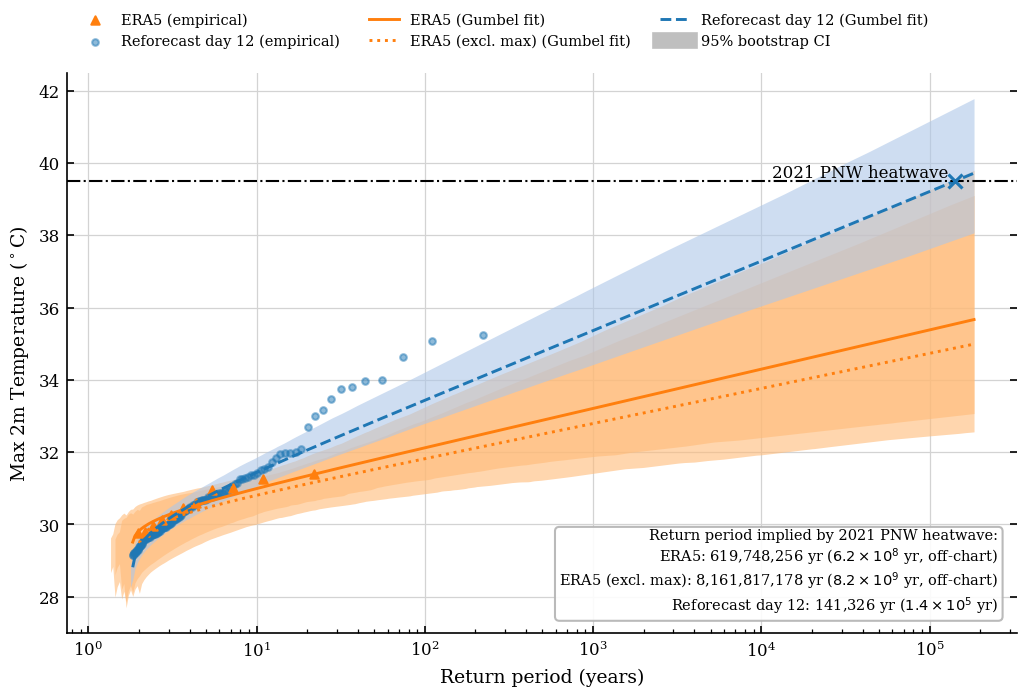

In [150]:
fig = plot_return_periods(fit_era5, fit_rf, era5_values, rf_values, LEAD_DAY,
                            fit_era5_excl_max=fit_era5_excl_max,
                            reference_value=REFERENCE_VALUE, reference_label=REFERENCE_LABEL)


'''fig = plot_return_periods(fit_era5, fit_rf, era5_values, rf_values, LEAD_DAY,
                            fit_era5_excl_max=fit_era5_excl_max,
                            reference_value=REFERENCE_VALUE, reference_label=REFERENCE_LABEL)'''
fig.savefig("gumbel_return_periods_values_t2m_no_max.pdf")
fig.savefig("gumbel_return_periods_values_t2m_no_max.png")
print("Saved -> gumbel_return_periods.pdf/.png")
#fig

## Empirical tail-slope plot

Saved -> gumbel_empirical_slope.pdf/.png
  ERA5: m=11  3.42x rarer per +1degC (R^2=0.91)
  ERA5 (excl. max): m=10  2.80x rarer per +1degC (R^2=0.96)
  Reforecast day 12: m=121  2.20x rarer per +1degC (R^2=0.98)
  CNRM-CM6-1: m=11  2.57x rarer per +1degC (R^2=0.97)
  CNRM-ESM2-1: m=11  1.99x rarer per +1degC (R^2=0.96)
  HadGEM3-GC31-LL: m=44  1.98x rarer per +1degC (R^2=0.96)
  IPSL-CM6A-LR: m=55  1.77x rarer per +1degC (R^2=0.97)


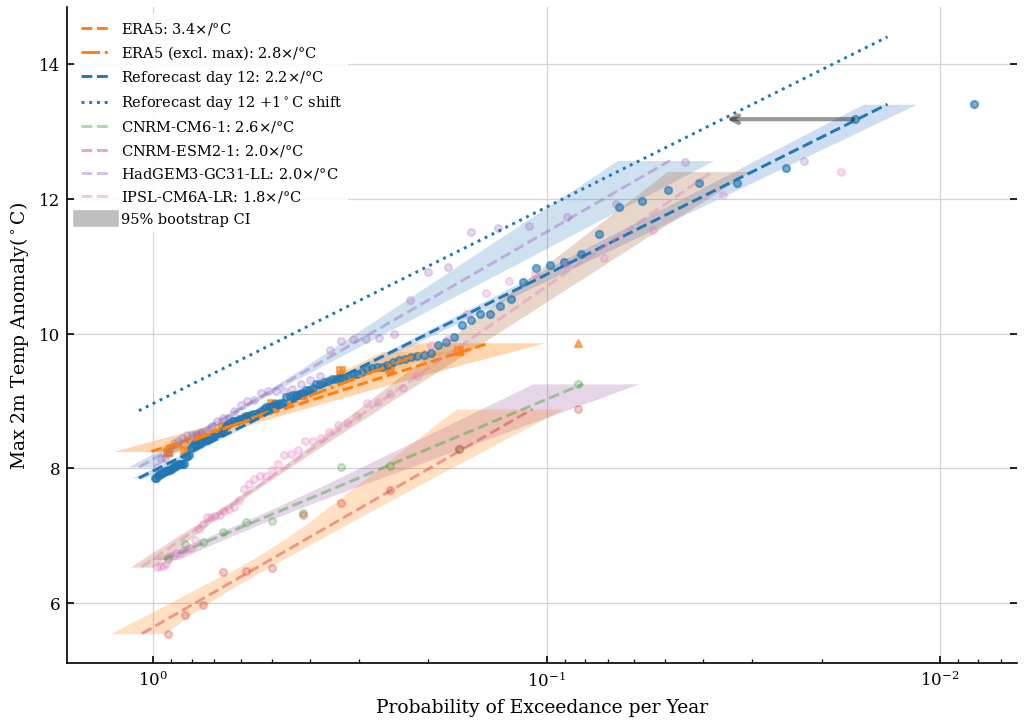

In [137]:
all_datasets = collect_empirical_slope_datasets(
    era5_values=era5_values, rf_values=rf_values, rf_label=f"Reforecast day {LEAD_DAY}",
    cmip_values=cmip_values,
)
fig_slope, datasets = plot_empirical_slopes(
    list(all_datasets.values()),
    warming_shift_dataset=WARMING_SHIFT_DATASET, warming_shift_degrees=WARMING_SHIFT_DEGREES,
)
fig_slope.savefig("gumbel_empirical_slope_raw_t2m.pdf")
fig_slope.savefig("gumbel_empirical_slope_raw_t2m.png")
print("Saved -> gumbel_empirical_slope.pdf/.png")
for ds in datasets:
    f = ds["_fit"]
    print(f"  {ds['name']}: m={f['m']}  {f['rarity_factor_per_plus1degC']:.2f}x rarer per +1degC (R^2={f['r2']:.2f})")
#fig_slope

In [138]:
def bootstrap_empirical_slope_ci_on_grid(
    fit,
    T_grid,
    n_boot=N_BOOTSTRAP,
    ci=CI_LEVEL,
    seed=BOOTSTRAP_SEED,
):
    """
    Bootstrap CI for the empirical-tail line, evaluated on a common temperature grid.
    Returns lower/upper probability bounds at each T in T_grid.
    """
    mags, log_probs = fit["exceedances"], fit["log_survival"]
    m = len(mags)
    rng = np.random.default_rng(seed)
    lines = np.full((n_boot, len(T_grid)), np.nan)

    for b in range(n_boot):
        idx = rng.integers(0, m, size=m)
        coeff = np.polyfit(mags[idx], log_probs[idx], 1)
        lines[b] = np.exp(np.polyval(coeff, T_grid))

    lo, hi = 100 * (1 - ci) / 2, 100 * (1 + ci) / 2
    with np.errstate(invalid="ignore"):
        return np.nanpercentile(lines, lo, axis=0), np.nanpercentile(lines, hi, axis=0)


def plot_empirical_slopes(
    datasets: list,
    warming_shift_dataset: str = None,
    warming_shift_degrees: float = 1.0,
):
    """
    Plots each dataset's empirical tail-slope together, as temperature anomaly, with
    probability-direction bootstrap CI bands. Optionally overlays a warming-shifted
    version of one dataset with an arrow showing how far the probability moves.
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    for ds in datasets:
        excl_max = ds.get("excl_max", False)
        fit_fn = empirical_tail_slope_excl_max if excl_max else empirical_tail_slope
        fit = fit_fn(ds["values"])

        c = ds.get("color", "#ff7f0e")
        marker = ds.get("marker", "o")
        ci_color = ds.get("ci", "#ffbb78")
        alpha = ds.get("alpha", 1.0)
        linestyle = ds.get("linestyle", "--")
        linewidth=ds.get("lineswidth", 1.4)

        prob = np.exp(fit["log_survival"])

        # Common temperature grid for BOTH the fit line and the bootstrap CI.
        T_grid = np.linspace(fit["exceedances"].min(), fit["exceedances"].max(), 200)
        prob_line = np.exp(fit["slope"] * T_grid + fit["intercept"])

        lower_prob, upper_prob = bootstrap_empirical_slope_ci_on_grid(fit, T_grid)
        ax.fill_betweenx(
            T_grid,
            lower_prob,
            upper_prob,
            color=ci_color,
            alpha=0.6 * alpha,
            linewidth=0,
            zorder=1,
        )

        ax.scatter(
            prob,
            fit["exceedances"],
            s=12,
            color=c,
            marker=marker,
            alpha=0.6 * alpha,
            zorder=3,
        )

        ax.plot(
            prob_line,
            T_grid,
            color=c,
            linewidth=linewidth,
            linestyle=linestyle,
            zorder=4,
            alpha=alpha,
            label=f"{ds['name']}: {fit['rarity_factor_per_plus1degC']:.1f}$\\times$/°C",
        )

        if warming_shift_dataset and ds["name"] == warming_shift_dataset:
            degrees = warming_shift_degrees

            ax.plot(
                prob_line,
                T_grid + degrees,
                color=c,
                linewidth=1.4,
                linestyle=":",
                zorder=4,
                alpha=alpha,
                label=f"{ds['name']} +{degrees:g}$^\\circ$C shift",
            )

            ref_mag = fit["exceedances"][-2] if fit["m"] >= 2 else fit["exceedances"][-1]
            prob_at_ref = np.exp(fit["slope"] * ref_mag + fit["intercept"])
            prob_shift_at_ref = np.exp(fit["slope"] * (ref_mag - degrees) + fit["intercept"])

            ax.annotate(
                "",
                xy=(prob_shift_at_ref, ref_mag),
                xytext=(prob_at_ref, ref_mag),
                arrowprops=dict(arrowstyle="->", color="black", lw=2, alpha=0.4),
                annotation_clip=False,
                zorder=5,
            )

        ds["_fit"] = fit

    ax.plot(
        [],
        [],
        color=COL["reference"],
        alpha=0.25,
        linewidth=8,
        label=f"{int(CI_LEVEL * 100)}% bootstrap CI",
    )
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Probability of Exceedance per Year")
    ax.set_ylabel(r"Max 2m Temp Anomaly($^\circ$C)")
    ax.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
    ax.tick_params(axis="x", which="both", top=False, labeltop=False)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="none",
        framealpha=0.9,
        fontsize=7,
        loc="best",
    )
    fig.tight_layout()
    return fig, datasets

Saved -> gumbel_empirical_slope_values_t2m.pdf/.png
  ERA5: m=11  3.42x rarer per +1degC (R^2=0.91)
  ERA5 (excl. max): m=10  2.80x rarer per +1degC (R^2=0.96)
  Reforecast day 12: m=121  2.06x rarer per +1degC (R^2=0.99)
  CNRM-CM6-1: m=11  2.57x rarer per +1degC (R^2=0.97)
  CNRM-ESM2-1: m=11  1.99x rarer per +1degC (R^2=0.96)
  HadGEM3-GC31-LL: m=44  1.98x rarer per +1degC (R^2=0.96)
  IPSL-CM6A-LR: m=55  1.77x rarer per +1degC (R^2=0.97)


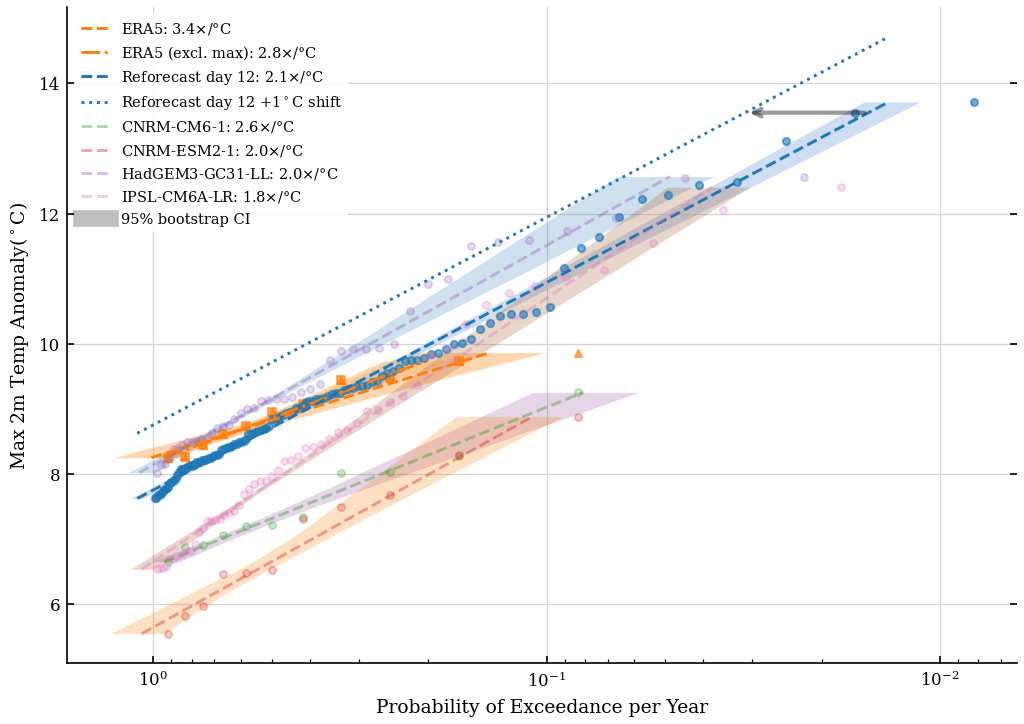

In [151]:
all_datasets = collect_empirical_slope_datasets(
    era5_values=era5_values,
    rf_values=rf_values,
    rf_label=f"Reforecast day {LEAD_DAY}",
    cmip_values=cmip_values,
)

fig_slope, datasets = plot_empirical_slopes(
    list(all_datasets.values()),
    warming_shift_dataset=WARMING_SHIFT_DATASET,
    warming_shift_degrees=WARMING_SHIFT_DEGREES,
)

fig_slope.savefig("gumbel_empirical_slope_values_t2m.pdf")
fig_slope.savefig("gumbel_empirical_slope_values_t2m.png")
print("Saved -> gumbel_empirical_slope_values_t2m.pdf/.png")

for ds in datasets:
    f = ds["_fit"]
    print(
        f"  {ds['name']}: m={f['m']}  "
        f"{f['rarity_factor_per_plus1degC']:.2f}x rarer per +1degC "
        f"(R^2={f['r2']:.2f})"
    )